In [1]:
"""
    File: modello.ipynb
    Author: Andrea Macale
    Date: 2026-03-04

    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici

"""

'\n    File: modello.ipynb\n    Author: Andrea Macale\n    Date: 2026-03-04\n\n    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici\n\n'

# Parte 0: Importazione delle librerie

In [2]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


## Librerie principali

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

In [4]:
import sys

# Si sposta nella directory principale dello Studio
#os.chdir('/teamspace/studios/this_studio')
path = os.path.expanduser('~/Documenti/Tesi-Magistrale')
os.chdir(path)
# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /home/andy/Documenti/Tesi-Magistrale


## Correlazione 

In [5]:
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import spearmanr

## VIF

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

## Distribuzione dei dati

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Train

In [68]:
import torch
import torchvision.transforms as T
import torch.nn as nn
from src.train.train import train_modello_visivo, train_modello_clinico
from src.models.DiagnosiIntegrata import DiagnosiIntegrata
from src.train.evaluator import Evaluator
from src.features.RXToraceDataset import RXToraceDataset
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer, util

# Parte 1: Estrazione dei dati

## Aperta dei file del dataset

In [9]:
pos_dataset = os.path.join("data")

In [10]:
file = os.path.join(pos_dataset, "patients.csv")
pazienti = pd.read_csv(file)
pazienti['subject_id'] = pazienti['subject_id'].astype(str)
pazienti.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [11]:
file = os.path.join(pos_dataset, "diagnoses_icd.csv")
tipi = {
    'subject_id': str, 
    'hadm_id': str, 
    'icd_code': str, 
    'icd_version': str
}
diagnosi = pd.read_csv(file, dtype=tipi)
diagnosi['icd_version'] = pd.to_numeric(diagnosi['icd_version'], errors='coerce').fillna(0).astype(int)
diagnosi = diagnosi.drop_duplicates()
diagnosi.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [12]:
file = os.path.join(pos_dataset, "mimic-cxr-2.0.0-metadata.csv")
metadati = pd.read_csv(file)
metadati['dicom_id'] = metadati['dicom_id'].astype(str)
metadati['subject_id'] = metadati['subject_id'].astype(str)
metadati['study_id'] = metadati['study_id'].astype(str)
metadati.head()

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN


In [13]:
file = os.path.join(pos_dataset, "icustays.csv")
visite = pd.read_csv(file)
visite['subject_id'] = metadati['subject_id'].astype(str)
visite.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000032,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000032,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10000032,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10000032,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [14]:
file = os.path.join(pos_dataset, "admissions.csv")
ammissioni = pd.read_csv(file)
ammissioni['subject_id'] = ammissioni['subject_id'].astype(str)
ammissioni

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546023,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaN,EW EMER.,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0
546024,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaN,EW EMER.,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0
546025,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1
546026,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaN,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0


In [15]:
lista_immagini = []
ricerca = Path(os.path.join(pos_dataset, "MIMIC_SUPER_RES_24K"))
for file_path in ricerca.rglob('*.jpg'):
    dicom_id = file_path.stem
    lista_immagini.append({'dicom_id': dicom_id, 'path_immagine': str(file_path)})
immagini = pd.DataFrame(lista_immagini)
immagini['path_immagine'] = immagini['path_immagine'].str.replace(str(pos_dataset+"/"), "data/", regex=False) # pulisci il path
immagini['dicom_id'] = immagini['dicom_id'].astype(str)
print(f"{len(immagini)} immagini")
immagini.head()

24000 immagini


,dicom_id,path_immagine
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...
1,152c3005-d0c7bf7a-4c0f7935-e82aef6e-bed96e2e,data/MIMIC_SUPER_RES_24K/152c3005-d0c7bf7a-4c0...
2,c4a20cd5-94e7d182-0bbca8a9-797c8bf5-7e12e050,data/MIMIC_SUPER_RES_24K/c4a20cd5-94e7d182-0bb...
3,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...
4,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...


In [16]:
def leggi_singolo_referto(file_path):
    """Funzione helper per la lettura parallela"""
    study_id = file_path.stem.replace("s", "")
    with open(file_path, 'r', encoding='utf-8') as f:
        testo = f.read()
    return {'study_id': str(study_id), 'testo_referto': testo}

lista_referti = []
ricerca_referti = Path(os.path.join(pos_dataset, "mimic-cxr-reports"))
files = list(ricerca_referti.rglob('*.txt'))

print(f"Inizio caricamento di {len(files)} file...")

# Usa ThreadPoolExecutor per saturare il Disk I/O
# Su Lightning AI T4 puoi usare tranquillamente 8 o 16 worker
with ThreadPoolExecutor(max_workers=8) as executor:
    lista_referti = list(tqdm(executor.map(leggi_singolo_referto, files), total=len(files)))

referti = pd.DataFrame(lista_referti)
print(f"Caricati {len(referti)} referti.")

Inizio caricamento di 227835 file...


100%|██████████| 227835/227835 [00:20<00:00, 10943.98it/s]

Caricati 227835 referti.


## Prima pulizia, selezione e join dei dati

In [17]:
dataset = pazienti.merge(metadati, on=['subject_id'], how='inner')
dataset = dataset.merge(visite, on=['subject_id'], how='inner')
dataset = dataset.merge(immagini, on=['dicom_id'], how='inner')
dataset = dataset.merge(referti, on=['study_id'], how='inner')
dataset = dataset.merge(ammissioni, on=['subject_id'], how='inner')
print(len(dataset))
dataset

1505640


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,...,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,P086OF,EMERGENCY ROOM,NaN,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2187-07-11 09:26:00,2187-07-11 20:09:00,0
1,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,P98ML1,EMERGENCY ROOM,NaN,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2183-11-07 01:05:00,2183-11-07 11:19:00,0
2,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,P40LGD,EMERGENCY ROOM,HOSPICE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2187-10-10 11:56:00,2187-10-10 23:11:00,0
3,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,P52V4D,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2187-08-23 14:37:00,2187-08-23 22:46:00,0
4,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,P68RWG,EMERGENCY ROOM,HOME,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2183-10-28 03:30:00,2183-10-28 10:39:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505635,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,P5069B,EMERGENCY ROOM,HOME HEALTH CARE,Private,English,MARRIED,WHITE,2187-04-23 18:26:00,2187-04-23 23:24:00,0
1505636,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,P31XHK,EMERGENCY ROOM,HOME,Private,English,MARRIED,WHITE,2184-07-14 16:15:00,2184-07-15 02:00:00,0
1505637,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,P42XKM,EMERGENCY ROOM,HOME HEALTH CARE,Private,English,MARRIED,WHITE,2187-06-10 19:26:00,2187-06-11 03:19:00,0
1505638,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,P55EL5,EMERGENCY ROOM,HOME HEALTH CARE,Private,English,MARRIED,WHITE,2184-09-07 01:33:00,2184-09-07 21:05:00,0


In [18]:
condizioni = [
    # STADIO IV: Metastasi (Il più grave)
    diagnosi['icd_code'].str.startswith(('196', '197', '198', '199', 'C77', 'C78', 'C79'), na=False),
    
    # STADIO I-III: Tumore Primario Invasivo
    diagnosi['icd_code'].str.startswith(('162', 'C34'), na=False),
    
    # Livello 2 - INJURIES (Traumi, fratture, contusioni)
    # Codici ICD-9 (800-999) e ICD-10 (S e T)
    diagnosi['icd_code'].str.startswith(('8', '9', 'S', 'T'), na=False),
    
    # A RISCHIO: Noduli o ombre (Sospetti non confermati)
    diagnosi['icd_code'].str.contains('793.1|R91', na=False)
]
valori = [4, 3, 2, 1]
diagnosi['numero_severita'] = np.select(condizioni, valori, default=0)
etichette_pazienti = diagnosi.groupby('subject_id')['numero_severita'].max().reset_index()
mappa_severita = {
    4: 'METASTATICO',
    3: 'PRIMARIO',
    2: 'TRAUMI',
    1: 'A RISCHIO',
    0: 'NEGATIVO'
}
etichette_pazienti['stato_clinico'] = etichette_pazienti['numero_severita'].map(mappa_severita)

In [19]:
dataset = dataset.merge(etichette_pazienti, on=['subject_id'], how='left')
dataset['numero_severita'] = pd.to_numeric(dataset['numero_severita'], errors='coerce')
dataset['numero_severita'] = dataset['numero_severita'].fillna(0)
dataset['numero_severita'] = dataset['numero_severita'].astype('int64')
dataset['stato_clinico'] = dataset['stato_clinico'].fillna('NEGATIVO')
dataset

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,...,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,numero_severita,stato_clinico
0,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,NaN,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2187-07-11 09:26:00,2187-07-11 20:09:00,0,4,METASTATICO
1,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,NaN,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2183-11-07 01:05:00,2183-11-07 11:19:00,0,4,METASTATICO
2,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,HOSPICE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2187-10-10 11:56:00,2187-10-10 23:11:00,0,4,METASTATICO
3,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,SKILLED NURSING FACILITY,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2187-08-23 14:37:00,2187-08-23 22:46:00,0,4,METASTATICO
4,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,HOME,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2183-10-28 03:30:00,2183-10-28 10:39:00,0,4,METASTATICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505635,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,HOME HEALTH CARE,Private,English,MARRIED,WHITE,2187-04-23 18:26:00,2187-04-23 23:24:00,0,2,TRAUMI
1505636,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,HOME,Private,English,MARRIED,WHITE,2184-07-14 16:15:00,2184-07-15 02:00:00,0,2,TRAUMI
1505637,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,HOME HEALTH CARE,Private,English,MARRIED,WHITE,2187-06-10 19:26:00,2187-06-11 03:19:00,0,2,TRAUMI
1505638,12510856,M,58,2181,2008 - 2010,NaN,0d381d46-328a3833-dc5d3193-0a5aa04a-19feb26b,59404749,CHEST (PORTABLE AP),AP,...,HOME HEALTH CARE,Private,English,MARRIED,WHITE,2184-09-07 01:33:00,2184-09-07 21:05:00,0,2,TRAUMI


# Parte 2: Gestione dei valori nulli e duplicati

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1505640 entries, 0 to 1505639
Data columns (total 43 columns):
 #   Column                                      Non-Null Count    Dtype  
---  ------                                      --------------    -----  
 0   subject_id                                  1505640 non-null  object 
 1   gender                                      1505640 non-null  object 
 2   anchor_age                                  1505640 non-null  int64  
 3   anchor_year                                 1505640 non-null  int64  
 4   anchor_year_group                           1505640 non-null  object 
 5   dod                                         895957 non-null   object 
 6   dicom_id                                    1505640 non-null  object 
 7   study_id                                    1505640 non-null  object 
 8   PerformedProcedureStepDescription           1445560 non-null  object 
 9   ViewPosition                                1505640 non-n

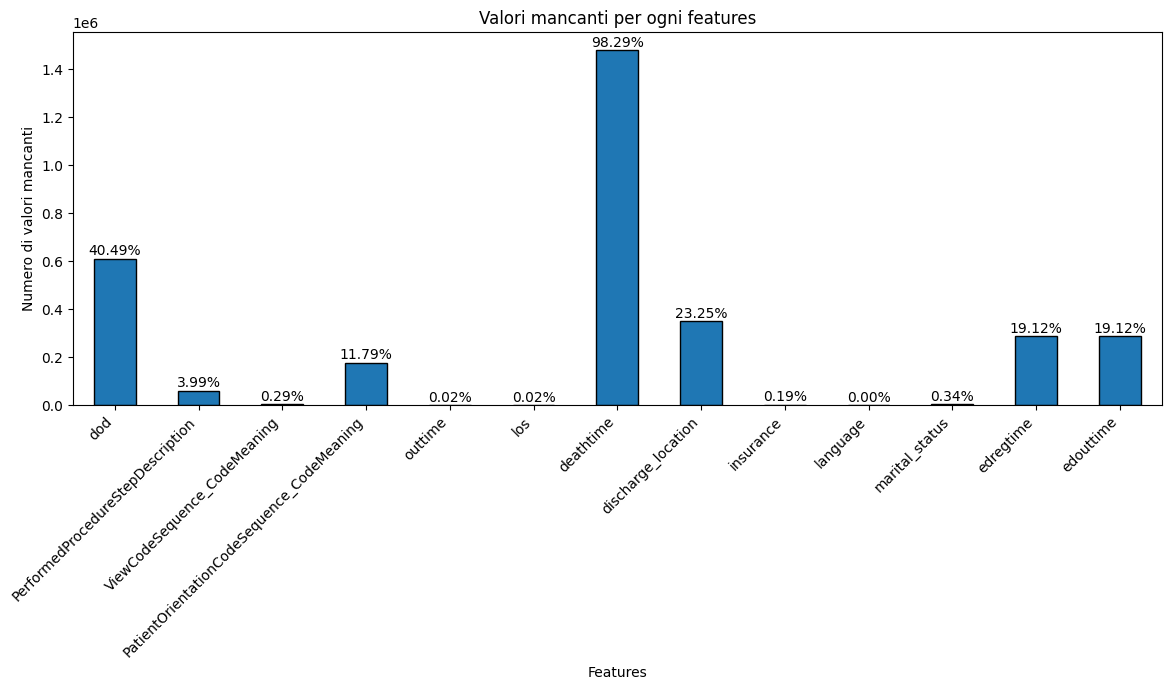

In [21]:
def plot_valori_mancanti(dataset):
    valori_nulli = dataset.isnull().sum()
    valori_nulli = valori_nulli[valori_nulli > 0]
    percentuale = valori_nulli / len(dataset) * 100
    plt.figure(figsize=(12, 7), dpi=100)
    valori_nulli.plot(kind='bar', edgecolor='black')
    for chiave, valore in enumerate(valori_nulli):
        plt.text(chiave, valore + (max(valori_nulli) * 0.01), f"{percentuale.iloc[chiave]:.2f}%", ha='center', fontsize=10)
    plt.title('Valori mancanti per ogni features')
    plt.ylabel('Numero di valori mancanti')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
        
plot_valori_mancanti(dataset)

Tutti i valori mancanti rappresentano dei dati inutili (eccetto los), perciò procedo con l'eliminazione delle features. Los, invece elimino quei pochissimi record (0,1%), poiché in campo medico è preferibile eliminare le indicisioni (visto la percentuale), piuttosto che generare rumore con l'imputazione.

In [22]:
dataset = dataset.dropna(subset=['los'])

## Gestione dei duplicati

Per prima cosa, si crea una feature unica datetime

In [23]:
dataset['StudyDate_str'] = dataset['StudyDate'].astype(int).astype(str)
dataset['StudyTime_str'] = dataset['StudyTime'].astype(int).astype(str)
dataset['StudyTime_str'] = dataset['StudyTime_str'].str.zfill(6) # HHMMSS
dataset['StudyDateTime'] = pd.to_datetime(
    dataset['StudyDate_str'] + dataset['StudyTime_str'],
    format='%Y%m%d%H%M%S',
    errors='coerce'
)

/tmp/ipykernel_4870/2468064653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['StudyDate_str'] = dataset['StudyDate'].astype(int).astype(str)
/tmp/ipykernel_4870/2468064653.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['StudyTime_str'] = dataset['StudyTime'].astype(int).astype(str)
/tmp/ipykernel_4870/2468064653.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

Adesso si prendono le date di ammissione (sempre in formato datetime) e si incrociano grazie ai metadati (vedi path dell'immagine) con una tolleranza di un giorno per il pronto soccorso

In [24]:
dataset['admittime'] = pd.to_datetime(dataset['admittime'])
dataset['dischtime'] = pd.to_datetime(dataset['dischtime'])
tolleranza = pd.Timedelta(days=1)
condizione = (dataset['StudyDateTime'] >= (dataset['admittime'] - tolleranza)) & (dataset['StudyDateTime'] <= dataset['dischtime'])
dataset_match = dataset[condizione].copy()
dataset_pulito = dataset_match.drop_duplicates(subset=['path_immagine'])
print(f"Righe originali (esplose): {len(dataset)}")
print(f"Immagini con ricovero verificato al secondo: {len(dataset_pulito)}")

Righe originali (esplose): 1505396
Immagini con ricovero verificato al secondo: 4413


/tmp/ipykernel_4870/1171055247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['admittime'] = pd.to_datetime(dataset['admittime'])
/tmp/ipykernel_4870/1171055247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['dischtime'] = pd.to_datetime(dataset['dischtime'])


In [25]:
dataset_pulito

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,numero_severita,stato_clinico,StudyDate_str,StudyTime_str,StudyDateTime
51,10001401,F,89,2131,2014 - 2016,NaN,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,PORTABLE ABDOMEN,AP,...,MARRIED,WHITE,NaN,NaN,0,2,TRAUMI,21310610,102234,2131-06-10 10:22:34
144,10001401,F,89,2131,2014 - 2016,NaN,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,CHEST (PA AND LAT),PA,...,MARRIED,WHITE,2131-06-19 17:14:00,2131-06-20 00:26:00,0,2,TRAUMI,21310619,193047,2131-06-19 19:30:47
233,10001401,F,89,2131,2014 - 2016,NaN,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,Performed Desc,PA,...,MARRIED,WHITE,2131-07-30 12:47:00,2131-07-31 01:35:00,0,2,TRAUMI,21310802,114559,2131-08-02 11:45:59
330,10001884,F,68,2122,2008 - 2010,2131-01-20,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9,50712381,CHEST (PORTABLE AP),AP,...,MARRIED,BLACK/AFRICAN AMERICAN,2131-01-07 13:36:00,2131-01-07 22:13:00,1,2,TRAUMI,21310112,045656,2131-01-12 04:56:56
1551,10001884,F,68,2122,2008 - 2010,2131-01-20,d5f12914-f14ffd99-3ff2ee54-6f0cbd0c-4c411a2c,51817555,CHEST (PORTABLE AP),AP,...,MARRIED,BLACK/AFRICAN AMERICAN,2130-10-08 12:27:00,2130-10-08 21:24:00,0,2,TRAUMI,21301008,171656,2130-10-08 17:16:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505539,12510330,M,27,2138,2014 - 2016,NaN,28063652-0f92eb5c-34c3a18f-6d7647b2-3acc3367,56855965,CHEST (PORTABLE AP),AP,...,NaN,UNKNOWN,2138-03-06 11:24:00,2138-03-06 15:12:00,0,2,TRAUMI,21380313,104048,2138-03-13 10:40:48
1505563,12510330,M,27,2138,2014 - 2016,NaN,8f20e6f8-49e76101-f75c4466-c1aecac6-329a50fd,57189266,CHEST (PORTABLE AP),AP,...,NaN,UNKNOWN,2138-03-06 11:24:00,2138-03-06 15:12:00,0,2,TRAUMI,21380313,043617,2138-03-13 04:36:17
1505587,12510643,F,52,2156,2008 - 2010,NaN,4c0fbf50-bfe6d157-eb3e772b-32cd8a09-fbc59eb9,50749727,CHEST (PORTABLE AP),AP,...,SINGLE,BLACK/AFRICAN AMERICAN,2163-11-03 10:34:00,2163-11-04 20:49:00,0,2,TRAUMI,21631103,171857,2163-11-03 17:18:57
1505597,12510856,M,58,2181,2008 - 2010,NaN,981aa051-92b87b0d-44342681-d4aee51c-027fee40,52658641,CHEST (PA AND LAT),PA,...,MARRIED,WHITE,2187-06-10 19:26:00,2187-06-11 03:19:00,0,2,TRAUMI,21870610,193434,2187-06-10 19:34:34


## Normalizzazione dei dati

Le colonne utili sono subject_id per la primary key, gender, anchor_age, ViewPosition, los, admission_type

In [26]:
colonne_buone = ['subject_id','gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto' , 'stato_clinico', 'numero_severita']
dataset = dataset_pulito[colonne_buone].copy()
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto', 'stato_clinico', 'numero_severita']


In [27]:
dataset.head()

,subject_id,gender,anchor_age,ViewPosition,los,admission_type,path_immagine,testo_referto,stato_clinico,numero_severita
51,10001401,F,89,AP,1.728912,SURGICAL SAME DAY ADMISSION,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,TRAUMI,2
144,10001401,F,89,PA,1.728912,OBSERVATION ADMIT,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,TRAUMI,2
233,10001401,F,89,PA,1.728912,OBSERVATION ADMIT,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,TRAUMI,2
330,10001884,F,68,AP,1.073553,OBSERVATION ADMIT,data/MIMIC_SUPER_RES_24K/7b25b3ed-e780a527-319...,FINAL REPORT\...,TRAUMI,2
1551,10001884,F,68,AP,1.073553,EW EMER.,data/MIMIC_SUPER_RES_24K/d5f12914-f14ffd99-3ff...,FINAL REPORT\...,TRAUMI,2


In [28]:
colonne_feature = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
feature = dataset[colonne_feature].copy()
encoder = LabelEncoder()
feature['gender'] = encoder.fit_transform(feature['gender'])
feature['ViewPosition'] = encoder.fit_transform(feature['ViewPosition'])
feature = pd.get_dummies(feature, columns=['admission_type'], drop_first=True, dtype=float)
feature = feature.astype(float)
feature.head()

,gender,anchor_age,ViewPosition,los,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT
51,0.0,89.0,0.0,1.728912,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144,0.0,89.0,1.0,1.728912,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
233,0.0,89.0,1.0,1.728912,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
330,0.0,68.0,0.0,1.073553,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1551,0.0,68.0,0.0,1.073553,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Matrice di correlazione e calcolo del VIF

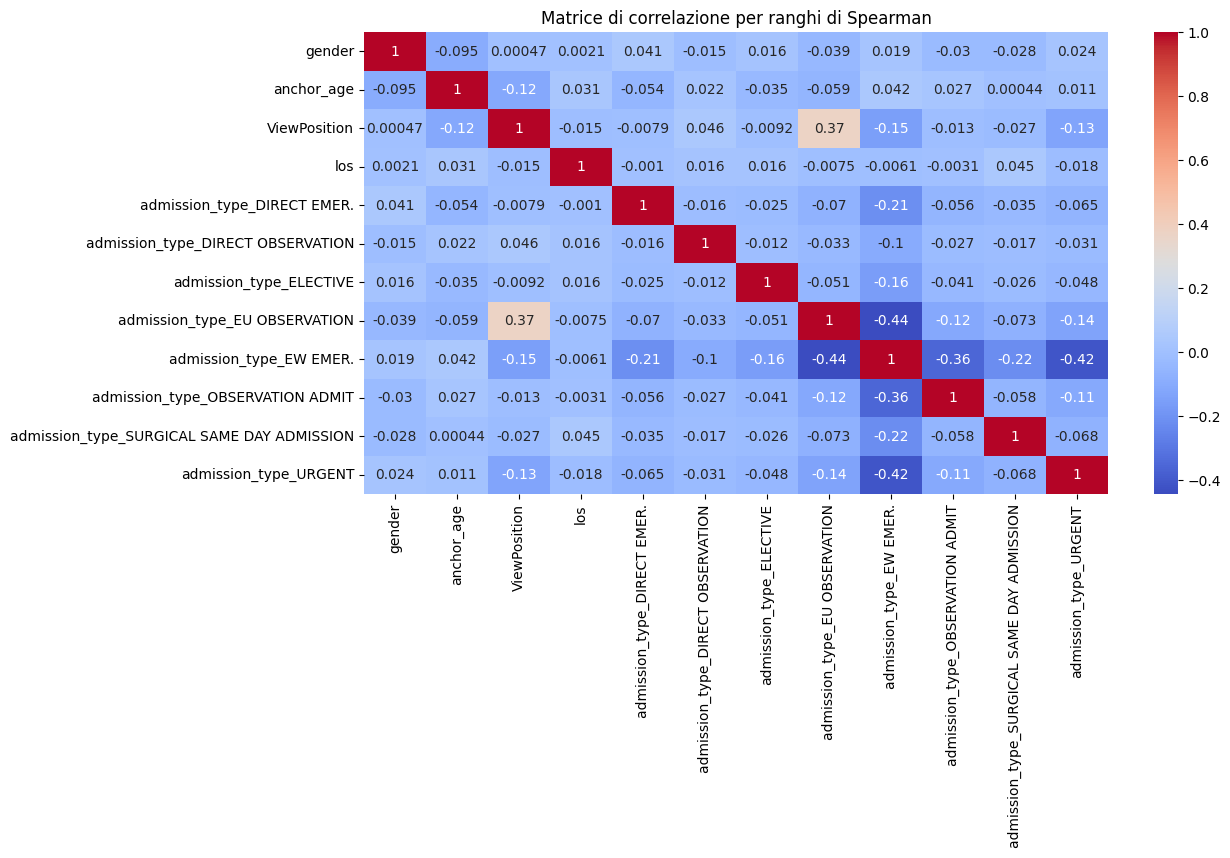

In [29]:
plt.figure(figsize=(12, 6))
plt.title('Matrice di correlazione per ranghi di Spearman')
sns.heatmap(feature.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

In [30]:
vif_data = pd.DataFrame()
vif_data['feature'] = feature.columns
feature_const = sm.add_constant(feature)
vif_data['VIF'] = [variance_inflation_factor(feature_const.values, ind+1) for ind in range(feature.shape[1])]
print(vif_data)

                                       feature        VIF
0                                       gender   1.015241
1                                   anchor_age   1.027029
2                                 ViewPosition   1.185315
3                                          los   1.003362
4                  admission_type_DIRECT EMER.   7.943573
5            admission_type_DIRECT OBSERVATION   2.682154
6                      admission_type_ELECTIVE   4.819811
7                admission_type_EU OBSERVATION  25.288721
8                      admission_type_EW EMER.  54.348875
9             admission_type_OBSERVATION ADMIT  18.269524
10  admission_type_SURGICAL SAME DAY ADMISSION   8.462298
11                       admission_type_URGENT  22.972826


Mapping dei dati

In [52]:
mapping_gender = {'M': 0, 'F': 1}
dataset['gender'] = dataset['gender'].map(mapping_gender)

posizioni_uniche = dataset['ViewPosition'].unique()
mapping_view = {pos: ind for ind, pos in enumerate(posizioni_uniche)}
dataset['ViewPosition'] = dataset['ViewPosition'].map(mapping_view)

ammissioni_uniche = dataset['admission_type'].unique()
mapping_admission = {tipo: ind for ind, tipo in enumerate(ammissioni_uniche)}
dataset['admission_type'] = dataset['admission_type'].map(mapping_admission)

dataset['anchor_age'] = pd.to_numeric(dataset['anchor_age'], errors='coerce').fillna(0).astype(int)
dataset['los'] = pd.to_numeric(dataset['los'], errors='coerce').fillna(0).astype(float)

colonne_mappate = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
print("Dtypes dopo la conversione:")
print(dataset[colonne_mappate].dtypes)

# Mostriamo i mapping (salvali per la tesi!)
print("\nMapping ViewPosition:", mapping_view)
print("Mapping AdmissionType:", mapping_admission)

Dtypes dopo la conversione:
gender              int64
anchor_age          int64
ViewPosition        int64
los               float64
admission_type      int64
dtype: object

Mapping ViewPosition: {'AP': 0, 'PA': 1}
Mapping AdmissionType: {'SURGICAL SAME DAY ADMISSION': 0, 'OBSERVATION ADMIT': 1, 'EW EMER.': 2, 'EU OBSERVATION': 3, 'URGENT': 4, 'DIRECT OBSERVATION': 5, 'DIRECT EMER.': 6, 'ELECTIVE': 7, 'AMBULATORY OBSERVATION': 8}


Come si può notare, ogni feature possiede colinearità debole, perciò è del tutto inutile eseguire procedure di riduzione di dimensionalità. Ovviamente, le colonne esplose hanno VIF altissimo, ma è del tutto normale

# Parte 3: Distribuzione dei dati

L'unico dato rilevante per calcolare gli outliers è l'anchor_age, poiché è l'unica variabile continua e può mostrare la demografia dei pazienti. I box-plot sugli altri dati non fornirebbe dati interessanti per il modello. Perciò, il box-plot viene fatto su anchor_age diviso per stadio_clinico, per vedere le fascie di età più colpite.

In [53]:
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto', 'stato_clinico', 'numero_severita']


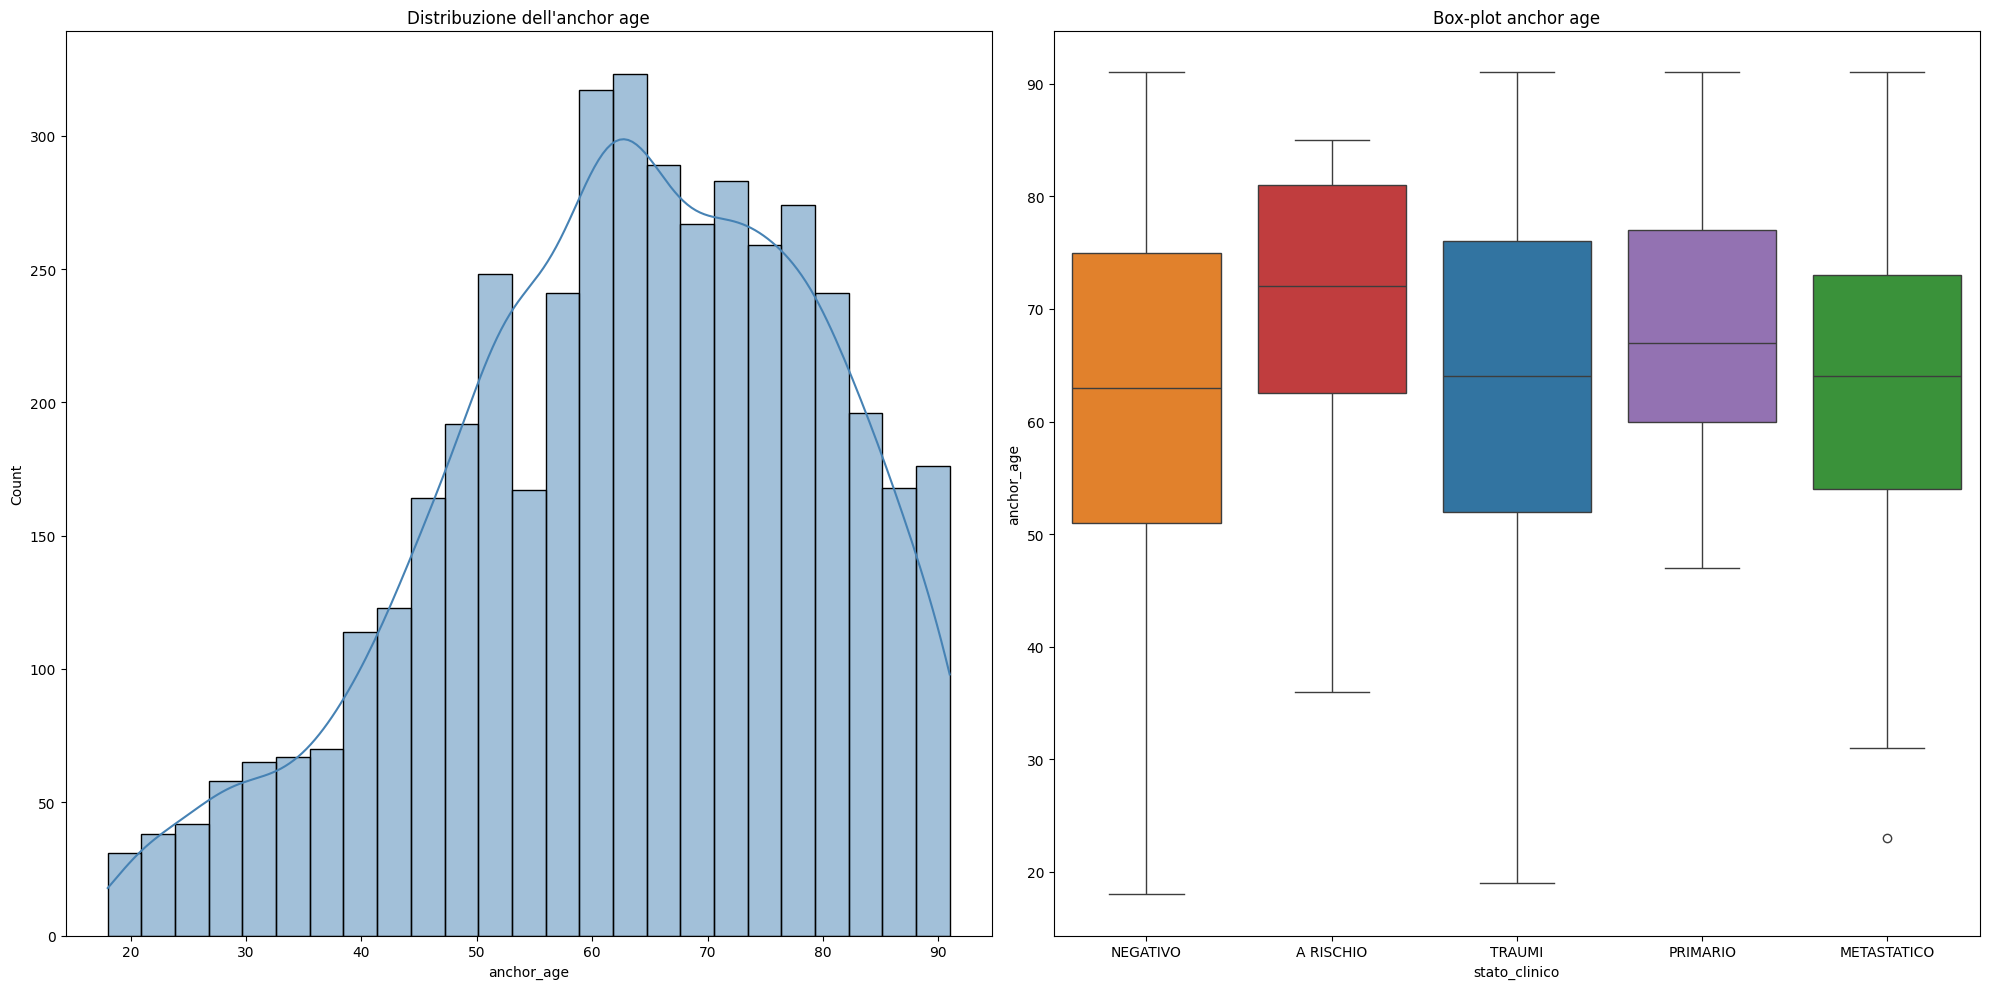

In [54]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
ordine_clinico = [
    'NEGATIVO', 
    'A RISCHIO',
    'TRAUMI',
    'PRIMARIO', 
    'METASTATICO'
]
sns.histplot(dataset['anchor_age'], kde=True, ax=axis[0], color='steelblue')
sns.boxplot(x='stato_clinico', y='anchor_age', data=dataset, order=ordine_clinico ,ax=axis[1], hue='stato_clinico', legend=False)
axis[0].set_title("Distribuzione dell'anchor age")
axis[1].set_title("Box-plot anchor age")
plt.tight_layout()
plt.show()

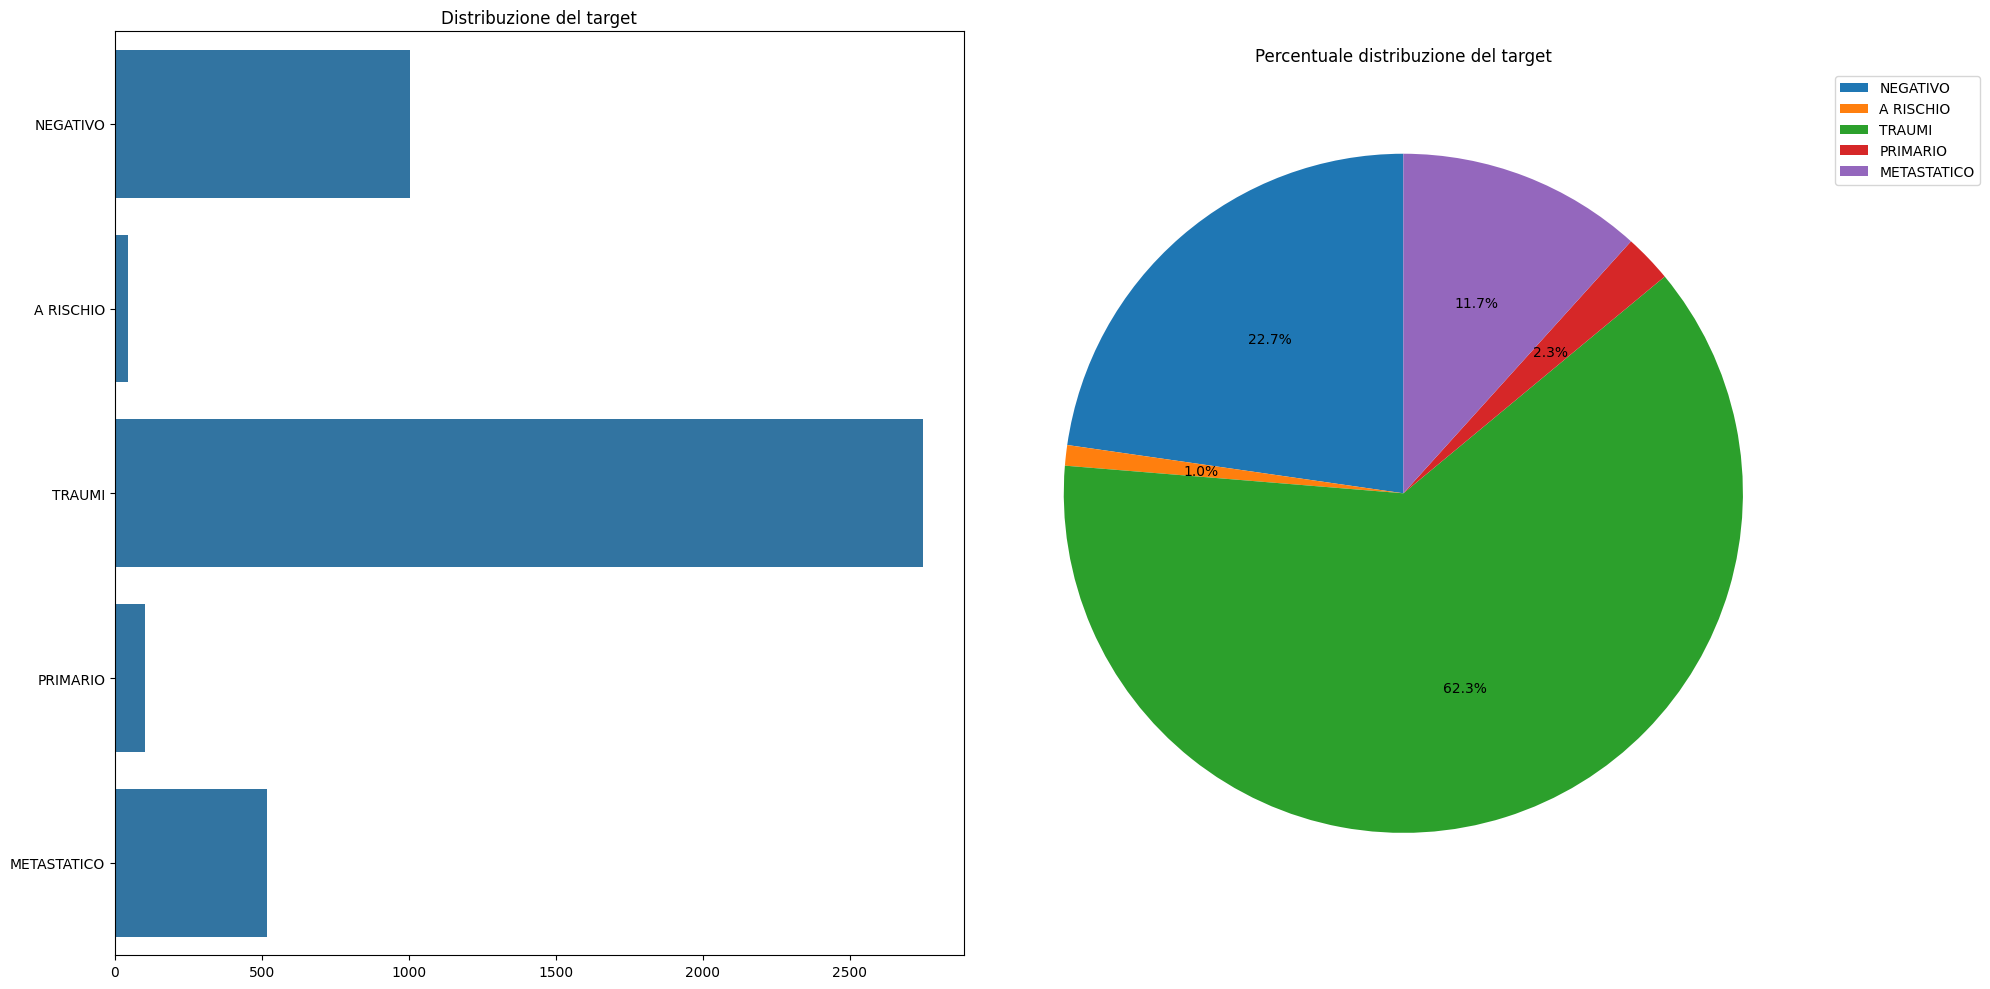

In [55]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
target_counts = dataset['stato_clinico'].value_counts().reindex(ordine_clinico).fillna(0)
sns.barplot(x=target_counts.values, y=ordine_clinico, ax=axis[0])
axis[1].pie(target_counts.values, labels=None, autopct='%1.1f%%', startangle=90)
axis[0].set_title("Distribuzione del target")
axis[1].set_title("Percentuale distribuzione del target")
axis[1].legend(labels=ordine_clinico, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Come si può notare, il dataset è molto sbilanciato di casi negativi. Per il momento, escludiamo i negativi.

Come si può notare, il dataset dei positivi risulta leggermente più bilanciato. Perciò, si procede con il data augumentation del I-III stadio, poiché i casi sono veramente rari; e con l'Weighted Cross-Entropy Loss, perché non è presente molta differenza con quelli a rischio. 

In [56]:
dataset_pazienti = dataset[['subject_id', 'numero_severita']].drop_duplicates(subset=['subject_id'])
train_pazienti, temp_pazienti = train_test_split(
    dataset_pazienti,
    test_size = 0.20,
    stratify = dataset_pazienti['numero_severita'],
    random_state = 42
)
val_pazienti, test_pazienti = train_test_split(
    temp_pazienti,
    test_size = 0.50,
    stratify = temp_pazienti['numero_severita'],
    random_state = 42
)
train_set = dataset[dataset['subject_id'].isin(train_pazienti['subject_id'])].copy()
validation_set = dataset[dataset['subject_id'].isin(val_pazienti['subject_id'])].copy()
test_set = dataset[dataset['subject_id'].isin(test_pazienti['subject_id'])].copy()
train_set

,subject_id,gender,anchor_age,ViewPosition,los,admission_type,path_immagine,testo_referto,stato_clinico,numero_severita
330,10001884,1,68,0,1.073553,1,data/MIMIC_SUPER_RES_24K/7b25b3ed-e780a527-319...,FINAL REPORT\...,TRAUMI,2
1551,10001884,1,68,0,1.073553,2,data/MIMIC_SUPER_RES_24K/d5f12914-f14ffd99-3ff...,FINAL REPORT\...,TRAUMI,2
3956,10002013,1,53,1,2.960637,2,data/MIMIC_SUPER_RES_24K/ab37274f-b4c1fc04-e2f...,FINAL REPORT\...,TRAUMI,2
6756,10003052,0,79,0,2.432998,3,data/MIMIC_SUPER_RES_24K/21560cb5-ffe886be-2a2...,FINAL REPORT\...,NEGATIVO,0
6795,10003400,1,72,0,0.939942,4,data/MIMIC_SUPER_RES_24K/581a33ce-5bd61881-296...,WET READ: ___ ___ ___ 8:53 PM\n The nasogast...,METASTATICO,4
...,...,...,...,...,...,...,...,...,...,...
1505539,12510330,0,27,0,5.951887,2,data/MIMIC_SUPER_RES_24K/28063652-0f92eb5c-34c...,FINAL REPORT\...,TRAUMI,2
1505563,12510330,0,27,0,5.951887,2,data/MIMIC_SUPER_RES_24K/8f20e6f8-49e76101-f75...,FINAL REPORT\...,TRAUMI,2
1505587,12510643,1,52,0,3.338646,3,data/MIMIC_SUPER_RES_24K/4c0fbf50-bfe6d157-eb3...,FINAL REPORT\...,TRAUMI,2
1505597,12510856,0,58,1,1.790995,2,data/MIMIC_SUPER_RES_24K/981aa051-92b87b0d-443...,WET READ: ___ ___ ___ 9:32 PM\n Left PICC is...,TRAUMI,2


In [57]:
print("--- DISTRIBUZIONE TRAIN SET ---")
print(train_set['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE TRAIN SET ---
stato_clinico
TRAUMI         2189
NEGATIVO        804
METASTATICO     414
PRIMARIO         88
A RISCHIO        33
Name: count, dtype: int64

Totale immagini per l'addestramento: 3528


## Data augmentation

In [58]:
base = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BILINEAR), 
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

augmentation = T.Compose([
    T.RandomResizedCrop(224, scale=(0.9, 1.0)), # Simula zoom/distanze diverse
    T.RandomRotation(degrees=7), # Aumentato leggermente a 7 gradi
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Traslazioni leggermente più marcate
    T.ColorJitter(brightness=0.2, contrast=0.2), # Fondamentale per RX: simula diverse esposizioni
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

## Undersampling

Per eseguire l'undersampling, trovo i pazienti sani simili, con la logica degli N-grammi e la Cosine Similarity.

In [59]:
model_st = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
df_traumi = train_set[train_set['stato_clinico'] == 'TRAUMI'].copy()
sentences = df_traumi['testo_referto'].tolist()
embeddings = model_st.encode(sentences, convert_to_tensor=True)
centroid = torch.mean(embeddings, dim=0)
cosine_scores = util.cos_sim(embeddings, centroid).flatten()
top_k_indices = torch.topk(cosine_scores, k=1000).indices.cpu().numpy()
df_traumi_top = df_traumi.iloc[top_k_indices]
altre_classi = train_set[train_set['numero_severita'] != 2]
train_set_sbilanciato = pd.concat([df_traumi_top, altre_classi]).sample(frac=1).reset_index(drop=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15879.35it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [60]:
def bilancia_dataframe_a_1000(df, df_traumi_top):
    target_n = 1000
    nuovi_pezzi = []
    
    for classe in [0, 1, 2, 3, 4]:
        if classe == 2:
            if df_traumi_top is not None and not df_traumi_top.empty:
                nuovi_pezzi.append(df_traumi_top)
        else:
            df_classe = df[df['numero_severita'] == classe]
            
            if not df_classe.empty:
                # Calcoliamo quante volte replicare la classe per arrivare a 1000
                moltiplicatore = (target_n // len(df_classe)) + 1
                df_aug = pd.concat([df_classe] * moltiplicatore, ignore_index=True)
                
                # Tagliamo esattamente a 1000 e aggiungiamo alla lista
                nuovi_pezzi.append(df_aug.iloc[:target_n])
            else:
                print(f"Attenzione: La classe {classe} è vuota nel dataframe di input!")
            
    # Ora la lista nuovi_pezzi contiene 5 dataframe da 1000 righe ciascuno
    return pd.concat(nuovi_pezzi).sample(frac=1).reset_index(drop=True)

# Ora lancia il comando
train_set_bilanciato = bilancia_dataframe_a_1000(train_set, df_traumi_top)

In [61]:
print("--- DISTRIBUZIONE FINALE TRAIN SET ---")
print(train_set_bilanciato['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE FINALE TRAIN SET ---
stato_clinico
NEGATIVO       1000
PRIMARIO       1000
A RISCHIO      1000
TRAUMI         1000
METASTATICO    1000
Name: count, dtype: int64

Totale immagini per l'addestramento: 3528


## Weighted Cross-Entropy

In [62]:
def calcola_pesi_loss(dataframe, augmentation=True):
    conta = dataframe['numero_severita'].value_counts()
    
    # Conteggi (assumendo Negativo e Traumi a 1000, gli altri originali)
    n0 = 1000  # NEGATIVO
    n1 = conta.get(1, 1) # A RISCHIO (33)
    n2 = 1000 # TRAUMI
    n3 = conta.get(3, 1) # PRIMARIO (88)
    n4 = conta.get(4, 1) # METASTATICO (414)

    if not augmentation:
        # Senza augmentation: pesi alti per compensare lo sbilanciamento
        pesi = [1.0, n0/n1, 1.0, n0/n3, n0/n4]
    else:
        # Con augmentation e oversampling: tutte le classi pesano uguale
        pesi = [1.0, 1.0, 1.0, 1.0, 1.0]
        
    return torch.tensor(pesi, dtype=torch.float32)

Con Augmentation

In [67]:
pesi_aug = calcola_pesi_loss(train_set, augmentation=True)
pesi_baseline = calcola_pesi_loss(train_set, augmentation=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Senza Augmentation

# Parte 4: Addestramento e risultati

In [65]:
ricerca_train = os.path.join(os.getcwd())

In [66]:
# Training clinico
feat_cols = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
clinical_model = train_modello_clinico(train_set_bilanciato, validation_set, feat_cols)


--- TRAINING MODELLO CLINICO ---
[0]	validation_0-mlogloss:1.60765
[100]	validation_0-mlogloss:1.51175
[200]	validation_0-mlogloss:1.47054
[300]	validation_0-mlogloss:1.43676
[400]	validation_0-mlogloss:1.41949
[499]	validation_0-mlogloss:1.40191


In [ ]:
from PIL import Image

# Disabilita il limite di sicurezza per le immagini mediche ad altissima risoluzione
Image.MAX_IMAGE_PIXELS = None

In [ ]:
# Training modello visivo con augmentation
modello_aug, hist_aug = train_modello_visivo(
    train_set_bilanciato, 
    validation_set, 
    ricerca_train, 
    base, 
    augmentation, 
    pesi=pesi_aug,
    device=device, 
    use_aug=True
)

In [ ]:
# Training modello visivo senza augmentation
modello_baseline, hist_baseline = train_modello_visivo(
    train_set_sbilanciato, 
    validation_set, 
    ricerca_train, 
    base, 
    augmentation, 
    pesi=pesi_baseline,
    device=device, 
    use_aug=False
)

In [ ]:
dataset_test = RXToraceDataset(
    dataframe=test_set, 
    cartella=ricerca_train, 
    transform_base=base, 
    transform_aug=None, 
    is_train=False
)
evaluator = Evaluator(['NEGATIVO', 'A RISCHIO', 'TRAUMI', 'PRIMARIO', 'METASTATICO'])

In [ ]:
evaluator.plot_training_history(
    history=hist_baseline, 
    title="Scenario A: Baseline (Dataset Sbilanciato)", 
    filename="baseline"
)

In [ ]:
evaluator.plot_training_history(
    history=hist_aug, 
    title="Scenario B: Augmented (Dataset Bilanciato)", 
    filename="augmented"
)